Using device: cuda
Epoch 1/100
VAE Loss: 107.9116
WGAN D Loss: -0.6275, G Loss: -11.5429
Epoch 2/100
VAE Loss: 79.3257
WGAN D Loss: -0.0396, G Loss: -10.4502
Epoch 3/100
VAE Loss: 75.4311
WGAN D Loss: -0.1281, G Loss: -1.1698
Epoch 4/100
VAE Loss: 73.5194
WGAN D Loss: -0.2981, G Loss: -1.8492
Epoch 5/100
VAE Loss: 72.3481
WGAN D Loss: -0.3853, G Loss: -3.1574
Epoch 6/100
VAE Loss: 71.4118
WGAN D Loss: -0.3845, G Loss: -3.2636
Epoch 7/100
VAE Loss: 70.6217
WGAN D Loss: -0.3809, G Loss: -2.4601
Epoch 8/100
VAE Loss: 70.0217
WGAN D Loss: -0.5362, G Loss: -2.0008
Epoch 9/100
VAE Loss: 69.4895
WGAN D Loss: -0.4720, G Loss: -2.0493
Epoch 10/100
VAE Loss: 69.1292
WGAN D Loss: -0.4892, G Loss: -1.7649
Epoch 11/100
VAE Loss: 68.6739
WGAN D Loss: -0.3587, G Loss: -1.8427
Epoch 12/100
VAE Loss: 68.3562
WGAN D Loss: -0.4515, G Loss: -1.3323
Epoch 13/100
VAE Loss: 67.9887
WGAN D Loss: -0.4448, G Loss: -1.4578
Epoch 14/100
VAE Loss: 67.6810
WGAN D Loss: -0.4110, G Loss: -1.3918
Epoch 15/100
VAE Loss

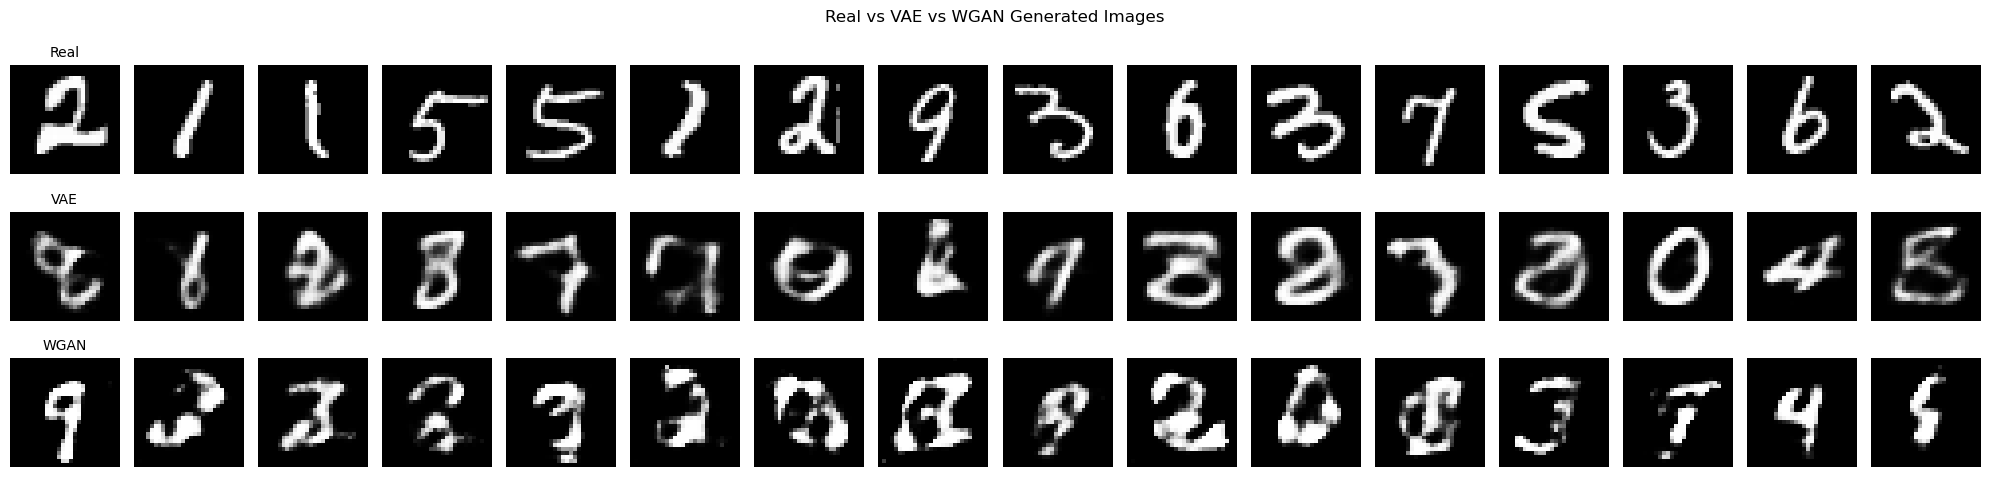

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# ==============================
#         设备配置
# ==============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ==============================
#         数据准备
# ==============================
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# ==============================
#         定义 VAE 模型
# ==============================
class VAE(nn.Module):
    def __init__(self, latent_dim=20):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim
        self.encoder = nn.Sequential(
            nn.Linear(28 * 28, 400),
            nn.ReLU(),
            nn.Linear(400, 40)  # 40 = 20 (均值) + 20 (方差)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 400),
            nn.ReLU(),
            nn.Linear(400, 28 * 28),
            nn.Tanh()  # 输出范围 [-1, 1]，与WGAN一致
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        x = x.view(-1, 28 * 28)
        h = self.encoder(x)
        mu, logvar = h[:, :self.latent_dim], h[:, self.latent_dim:]
        z = self.reparameterize(mu, logvar)
        x_recon = self.decoder(z)
        return x_recon, mu, logvar

def vae_loss(recon_x, x, mu, logvar):
    recon_loss = F.mse_loss(recon_x, x.view(-1, 28 * 28), reduction='sum')  # 使用MSE损失
    kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_div

# ==============================
#         定义 WGAN 模型
# ==============================
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.model(x)

class Generator(nn.Module):
    def __init__(self, latent_dim=100):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 784),
            nn.Tanh()
        )

    def forward(self, z):
        return self.model(z).view(z.size(0), 1, 28, 28)

# ==============================
#       初始化模型和优化器
# ==============================
# VAE
vae = VAE(latent_dim=20).to(device)
vae_optimizer = optim.Adam(vae.parameters(), lr=1e-3)

# WGAN
latent_dim_wgan = 100
generator = Generator(latent_dim=latent_dim_wgan).to(device)
discriminator = Discriminator().to(device)
g_optimizer = optim.RMSprop(generator.parameters(), lr=0.00005)
d_optimizer = optim.RMSprop(discriminator.parameters(), lr=0.00005)
clip_value = 0.01

# ==============================
#          训练参数
# ==============================
epochs = 100
n_critic = 5

# ==============================
#          训练模型
# ==============================
vae.train()
generator.train()
discriminator.train()

for epoch in range(epochs):
    vae_loss_total = 0
    d_loss_total = 0
    g_loss_total = 0

    for batch_idx, (real_imgs, _) in enumerate(train_loader):
        real_imgs = real_imgs.to(device)
        batch_size = real_imgs.size(0)

        # 训练 VAE
        vae_optimizer.zero_grad()
        recon_batch, mu, logvar = vae(real_imgs)
        vae_loss_value = vae_loss(recon_batch, real_imgs, mu, logvar)
        vae_loss_value.backward()
        vae_optimizer.step()
        vae_loss_total += vae_loss_value.item()

        # 训练 WGAN - 判别器
        d_optimizer.zero_grad()
        real_validity = discriminator(real_imgs)
        z = torch.randn(batch_size, latent_dim_wgan).to(device)
        fake_imgs = generator(z)
        fake_validity = discriminator(fake_imgs.view(fake_imgs.size(0), -1))
        d_loss = -torch.mean(real_validity) + torch.mean(fake_validity)
        d_loss.backward()
        d_optimizer.step()
        for p in discriminator.parameters():
            p.data.clamp_(-clip_value, clip_value)
        d_loss_total += d_loss.item()

        # 训练 WGAN - 生成器
        if batch_idx % n_critic == 0:
            g_optimizer.zero_grad()
            z = torch.randn(batch_size, latent_dim_wgan).to(device)
            gen_imgs = generator(z)
            fake_validity = discriminator(gen_imgs.view(gen_imgs.size(0), -1))
            g_loss = -torch.mean(fake_validity)
            g_loss.backward()
            g_optimizer.step()
            g_loss_total += g_loss.item()

    print(f"Epoch {epoch + 1}/{epochs}")
    print(f"VAE Loss: {vae_loss_total / len(train_loader.dataset):.4f}")
    print(f"WGAN D Loss: {d_loss_total / len(train_loader):.4f}, G Loss: {g_loss_total / (len(train_loader) // n_critic):.4f}")

# ==============================
#     生成图像并与真实图像比较
# ==============================
vae.eval()
generator.eval()
with torch.no_grad():
    # 获取真实图像
    real_imgs, _ = next(iter(train_loader))
    real_imgs = real_imgs[:16].cpu().numpy()  # 取16张真实图片

    # 生成 VAE 图像
    z_vae = torch.randn(16, 20).to(device)
    vae_imgs = vae.decoder(z_vae).cpu().view(-1, 1, 28, 28).numpy()

    # 生成 WGAN 图像
    z_wgan = torch.randn(16, latent_dim_wgan).to(device)
    wgan_imgs = generator(z_wgan).cpu().numpy()

# 可视化对比
fig, axes = plt.subplots(3, 16, figsize=(20, 5))
plt.suptitle("Real vs VAE vs WGAN Generated Images")

# 真实图像
for i, ax in enumerate(axes[0]):
    ax.imshow(real_imgs[i][0], cmap='gray')
    ax.axis('off')
axes[0, 0].set_title("Real", fontsize=10)

# VAE 生成图像
for i, ax in enumerate(axes[1]):
    ax.imshow(vae_imgs[i][0], cmap='gray')
    ax.axis('off')
axes[1, 0].set_title("VAE", fontsize=10)

# WGAN 生成图像
for i, ax in enumerate(axes[2]):
    ax.imshow(wgan_imgs[i][0], cmap='gray')
    ax.axis('off')
axes[2, 0].set_title("WGAN", fontsize=10)

plt.tight_layout()
plt.show()